# Supervised Learning - Classification Path

## Hotel Booking Cancellation Specialist (Operasional Perhotelan / Pariwisata)

### Metodologi Standar Industri: CRISP-DM
Sesuai standar global, kita akan membedah proyek ini menggunakan kerangka **CRISP-DM**:
1. **Business Understanding:** Mendefinisikan tujuan proyek untuk meminimalkan kerugian hotel akibat pembatalan dengan menetapkan target teknis berupa identifikasi pola pembatalan dan pencapaian skor model yang stabil
2. **Data Understanding:** proses pemeriksaan struktur data, seperti pengecekan dimensi dataset (119.390 baris), tipe data, jumlah data kosong, serta analisis distribusi variabel target (Check-out vs Canceled)
3. **Data Preparation:** langkah-langkah teknis untuk membersihkan dan mentransformasi data mentah, termasuk penanganan nilai kosong, encoding data kategori, dan standarisasi skala agar siap digunakan oleh model AI
4. **Modeling:** Melatih dan menyimulasikan isi kepala berbagai algoritma klasifikasi (Logistic Regression, KNN, SVM, Random Forest, dan XGBoost) untuk menemukan pola terbaik dalam memprediksi pembatalan
5. **Evaluation:** tahap pengujian kualitas model menggunakan data ujian (test set) melalui metrik evaluasi seperti Confusion Matrix, Akurasi, Recall, dan F1-Score untuk menentukan model yang paling layak digunakan

In [44]:
# Import semua library yang dibutuhkan sepanjang notebook

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    recall_score, f1_score, classification_report
)

from scipy.stats import chi2_contingency

print("Library sudah siap untuk digunakan")

Library sudah siap untuk digunakan


## BAB 1: Business Understanding

**Hotel Booking Cancellation Specialist (Operasional Perhotelan / Pariwisata)**

Bagian ini menjelaskan peran proyek sebagai solusi cerdas bagi operasional hotel untuk memprediksi risiko pembatalan secara dini
. Fokus utamanya adalah menjawab tiga target wajib: mengidentifikasi pola lead time dan deposit, membersihkan data agen serta preferensi kamar, dan membangun model klasifikasi dengan F1-Score minimal 82%

* **3 Target Wajib (Goals Utama):** 
*	Mengidentifikasi pola jarak waktu pemesanan (lead time) dan jenis jaminan deposit yang paling rentan memicu pembatalan pemesanan sepihak.
*	Wajib membersihkan data kosong (missing values) secara tepat pada kolom agen pengirim dan riwayat preferensi kamar tamu.
*	Membangun arsitektur model klasifikasi dengan tingkat kestabilan F1-Score minimal >= 82% pada data pengujian.
* **Pendekatan AI:** `Supervised Learning - Binary Classification`.

## BAB 2: Data Understanding
Tahap ini menjelaskan eksplorasi awal terhadap dataset yang memiliki 32 fitur
. Di sini dilakukan pengecekan bahwa terdapat 129.425 data kosong secara total dan distribusi target menunjukkan bahwa 37% dari total pemesanan berakhir dengan pembatalan, yang menandakan perlunya penanganan khusus pada ketidakseimbangan data

In [45]:
# Tampilkan semua kolom saat print DataFrame
pd.set_option('display.max_columns', 33)

In [46]:

# distribusi target, dan statistik dasar
df = pd.read_csv('dataset/dataset_hotel.csv')

print(f"Banyak hotel di pesan: {df.shape[0]} | Banyak Fitur hotel: {df.shape[1]}")
print(f"Data Kosong (Missing Values): {df.isnull().sum().sum()} buah\n")

distribusi = df['is_canceled'].value_counts(normalize=True) * 100
print(f"Hotel di Check Out (0) : {distribusi[0]:.1f}%")
print(f"Hotel di canceled (1) : {distribusi[1]:.1f}%\n")

display(df.describe())
df.info()

Banyak hotel di pesan: 119390 | Banyak Fitur hotel: 32
Data Kosong (Missing Values): 129425 buah

Hotel di Check Out (0) : 63.0%
Hotel di canceled (1) : 37.0%



,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [47]:
# Lihat 5 baris pertama dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [48]:
# Lihat 5 baris terakhir dataset
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## BAB 3: Data Cleaning
Bab ini menjelaskan proses pembersihan data secara detail, seperti mengisi kolom children dengan nilai median, mengisi kolom country dengan label "unknown", serta mengubah kolom agent menjadi tipe integer setelah mengisi nilai kosong dengan angka 0
. Selain itu, diputuskan untuk mempertahankan data duplikat (40.176 baris) karena dianggap merepresentasikan pesanan grup yang valid dalam operasional hotel

In [49]:
# Hitung jumlah missing value per kolom
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [50]:
## children: isi dengan median
# Missing hanya 4 baris ? terlalu sedikit untuk dihapus.
# Median dipilih karena distribusi children condong ke kanan (skewed).
df['children'] = df['children'].fillna(df['children'].median())

print("Data kosong pada kolom 'children' sudah diisi dengan median.")

Data kosong pada kolom 'children' sudah diisi dengan median.


In [51]:
## country: isi dengan 'unknown'
# Missing sebanyak 488 baris ? kemungkinan negara tidak dicatat saat booking.
# Diisi 'unknown' agar baris tidak hilang dan tetap bisa dianalisis.
df['country'] = df['country'].fillna("unknown")

print("Data kosong pada kolom 'country' sudah diisi dengan 'unknown'.")

Data kosong pada kolom 'country' sudah diisi dengan 'unknown'.


In [52]:
## agent: isi dengan 0
# Missing ~16.000 baris ? kemungkinan tamu booking langsung tanpa agen.
# Nilai 0 mewakili 'tanpa agen' sehingga bermakna secara bisnis.
df['agent'] = df['agent'].fillna(0)
df['agent'] = df['agent'].astype(int)

print("Data kosong pada kolom 'agent' sudah diisi dengan 0 dan tipe data diubah menjadi integer.")

Data kosong pada kolom 'agent' sudah diisi dengan 0 dan tipe data diubah menjadi integer.


In [53]:
## company: hapus kolom
# ~94% datanya kosong ? terlalu banyak untuk diisi dan berpotensi menambah noise.
df = df.drop(columns=["company"])

print("Kolom 'company' sudah dihapus karena banyak data kosong dan kurang membantu model.")

Kolom 'company' sudah dihapus karena banyak data kosong dan kurang membantu model.


In [54]:
# Konfirmasi semua missing value sudah tertangani
print(f"Data Kosong (Missing Values): {df.isnull().sum().sum()} buah\n")

Data Kosong (Missing Values): 0 buah



In [55]:
# Cek jumlah baris duplikat dan pola di baliknya
duplicate_rows = df[df.duplicated(keep=False)]

print("Jumlah data duplikat:", duplicate_rows.shape[0])

# Kelompokkan berdasarkan agent dan tanggal untuk melihat apakah duplikat berasal dari group booking
bukti_duplicate = duplicate_rows.groupby(
    ['agent', 'arrival_date_year',
     'arrival_date_month',
     'arrival_date_day_of_month']
).size().reset_index(name='Jumlah_Pemesanan')

display(
    bukti_duplicate.sort_values(
        by='Jumlah_Pemesanan',
        ascending=False
    ).head(10)
)

# Insight:
# Duplikat banyak berasal dari agen yang sama pada tanggal yang sama,
# menandakan ini adalah group booking, bukan kesalahan data.
# Data duplikat dipertahankan agar model bisa belajar pola pembatalan grup.

Jumlah data duplikat: 40176


,agent,arrival_date_year,arrival_date_month,arrival_date_day_of_month,Jumlah_Pemesanan
753,6,2015,October,16,257
760,6,2015,September,18,250
739,6,2015,August,14,232
255,0,2016,November,7,182
2026,19,2015,December,8,160
2492,56,2016,October,13,158
2361,37,2016,February,17,150
400,0,2017,March,2,147
429,0,2017,May,15,147
171,0,2016,February,19,145


Kesimpulan:
Data duplikat dipertahankan karena merepresentasikan pesanan grup yang valid dalam operasional hotel, guna memastikan model dapat menangkap seluruh pola perilaku pemesanan secara utuh dan akurat.

## BAB 4: EDA (Exploratory Data Analysis)
Tahap ini menjelaskan analisis visual untuk menemukan wawasan bisnis, seperti temuan bahwa tamu yang membatalkan memiliki lead time yang lebih tinggi (jarak pesan lebih lama) dan mayoritas pembatalan berasal dari pemesanan tanpa deposit atau tipe Non Refund pada segmen tertentu
. Analisis korelasi juga dilakukan untuk melihat fitur mana yang memiliki pengaruh positif atau negatif terkuat terhadap pembatalan

### 4.1 Analisis Visual: Distribusi countplot

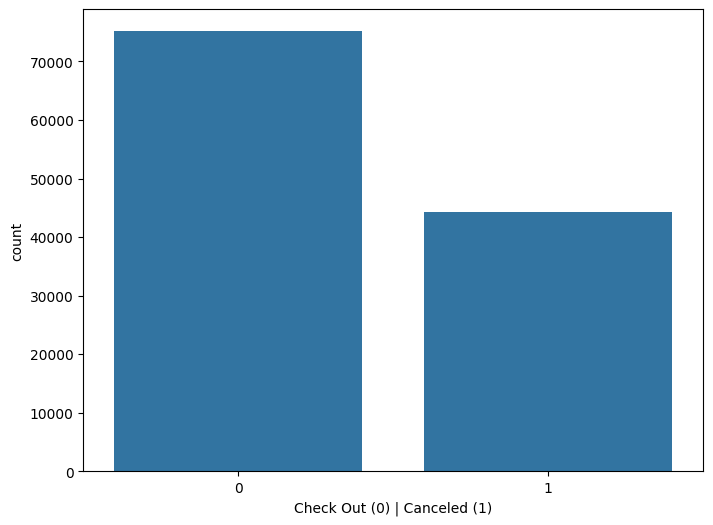

In [56]:
# Visualisasi distribusi target: berapa banyak yang check-out vs batal
plt.figure(figsize=(8, 6))

sns.countplot(x='is_canceled', data=df)
plt.xlabel('Check Out (0) | Canceled (1)')
plt.show()

# Insight:
# Data tidak seimbang ? lebih banyak check-out daripada pembatalan.
# Perlu strategi khusus (class_weight / scale_pos_weight) agar model tidak bias ke kelas mayoritas.

### 4.2 Analisis Visual: boxplot (Lead Time vs Cancellation) 🎯

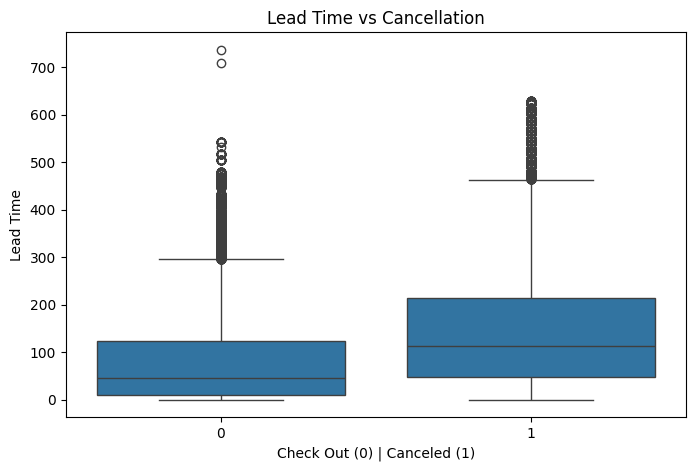

In [57]:
# Boxplot lead_time vs status pembatalan
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='is_canceled',
    y='lead_time',
    data=df
)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Check Out (0) | Canceled (1)')
plt.ylabel('Lead Time')

plt.show()

# Insight:
# Tamu yang membatalkan punya lead time lebih tinggi.
# Semakin lama jarak antara pemesanan dan check-in, semakin besar kemungkinan pembatalan.

### 4.3 Analisis Visual: countplot (Deposit Type vs Cancellation)  🎯

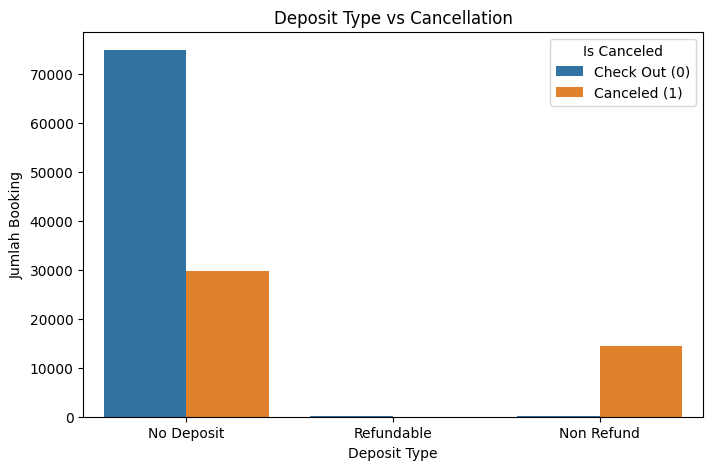

In [58]:
# Countplot deposit_type vs status pembatalan
plt.figure(figsize=(8,5))

sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df
)

plt.title('Deposit Type vs Cancellation')
plt.xlabel('Deposit Type')
plt.ylabel('Jumlah Booking')
plt.legend(title='Is Canceled', labels=['Check Out (0)', 'Canceled (1)'])

plt.show()

# Insight:
# Booking 'No Deposit' punya tingkat pembatalan lebih tinggi.
# Tamu tanpa deposit lebih mudah membatalkan karena tidak ada kerugian finansial.

### 4.4 Analisis Visual: countplot (Market Segment vs Cancellation)

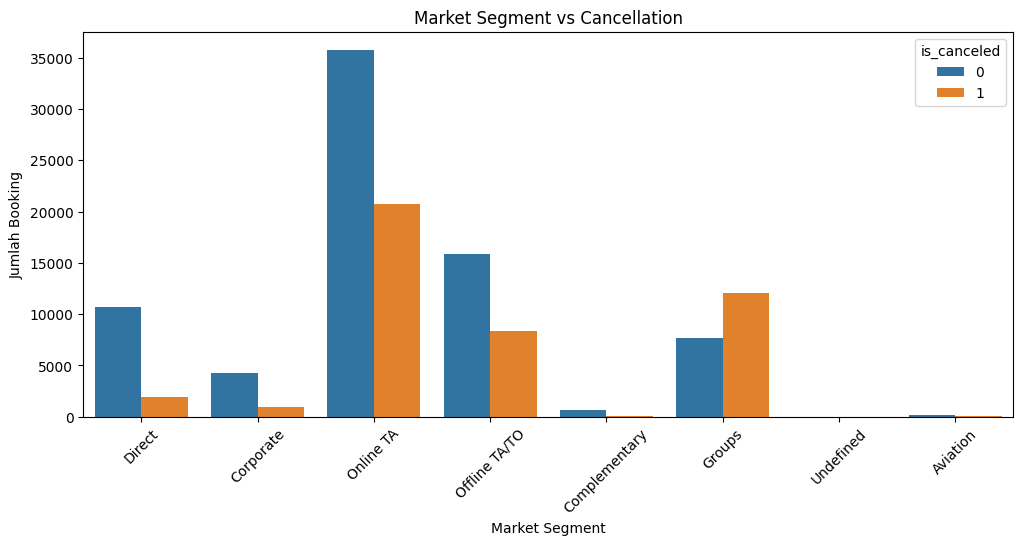

In [59]:
# Countplot market_segment vs status pembatalan
plt.figure(figsize=(12,5))

sns.countplot(
    x='market_segment',
    hue='is_canceled',
    data=df
)

plt.title('Market Segment vs Cancellation')
plt.xlabel('Market Segment')
plt.ylabel('Jumlah Booking')

plt.xticks(rotation=45)

plt.show()

# Insight:
# Segment 'Online TA' punya volume booking tertinggi sekaligus tingkat pembatalan tertinggi.
# Kemudahan akses platform online memungkinkan tamu lebih mudah membatalkan pesanan.

### 4.5 Analisis Visual: boxplot (ADR vs Cancellation)

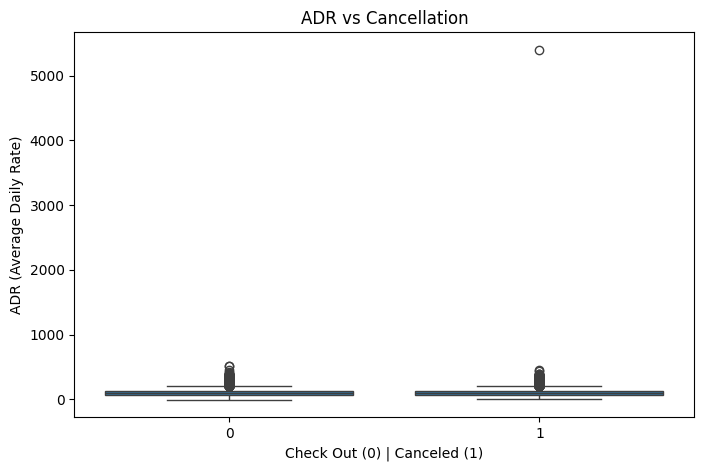

In [60]:
# Boxplot ADR vs status pembatalan
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='adr',
    data=df
)

plt.title('ADR vs Cancellation')
plt.xlabel('Check Out (0) | Canceled (1)')
plt.ylabel('ADR (Average Daily Rate)')

plt.show()

# Insight:
# Tamu yang batal cenderung memiliki ADR lebih rendah,
# mengindikasikan sensitivitas harga sebagai salah satu pemicu pembatalan.

### 4.6 Analisis Visual: Heatmap Korelasi

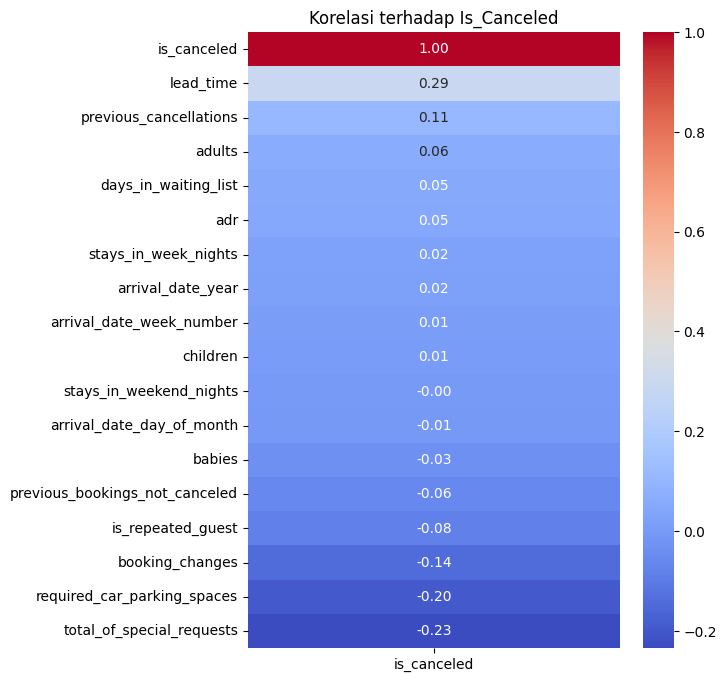

In [61]:
# Heatmap korelasi setiap fitur numerik terhadap target is_canceled
# Kolom 'agent' dikecualikan karena berupa ID nominal, bukan nilai kontinu
numerik = df.select_dtypes(include=['int64', 'float64']).drop(columns=['agent'], errors='ignore')

corr_target = numerik.corr()[['is_canceled']].sort_values(
    by='is_canceled',
    ascending=False
)

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Korelasi terhadap Is_Canceled")
plt.show()

# Insight:
# lead_time dan previous_cancellations punya korelasi positif tertinggi terhadap pembatalan.
# total_of_special_requests dan adr berkorelasi negatif ? tamu yang engaged cenderung tidak batal.

## BAB 5: Data Preparation
Bagian ini menjelaskan langkah teknis akhir sebelum pemodelan, yaitu menghapus kolom pemicu kebocoran data (data leakage) seperti reservation_status, melakukan One-Hot Encoding untuk mengubah teks menjadi angka, serta menerapkan StandardScaler untuk menyeragamkan rentang nilai fitur agar model lebih stabil

In [62]:
# Buang kolom bocor data, buat fitur baru, encode, split, lalu scaling

# Hapus kolom yang bocor informasi target
kolom_bocor = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=[col for col in kolom_bocor if col in df.columns]).copy()

# Feature engineering ? dibuat sebelum split agar ikut masuk ke training data
holiday_months = ['July', 'August', 'December']
df_clean['is_holiday_season'] = df_clean['arrival_date_month'].apply(
    lambda x: 1 if x in holiday_months else 0
)
df_clean['is_room_mismatch'] = (
    df_clean['reserved_room_type'] != df_clean['assigned_room_type']
).astype(int)

print("Fitur is_holiday_season dan is_room_mismatch berhasil dibuat dan dimasukkan ke pipeline.\n")

# Frequency encoding untuk 'country' ? lebih efisien dari OHE yang menghasilkan 170+ kolom
freq_country = df_clean['country'].value_counts(normalize=True)
df_clean['country_freq'] = df_clean['country'].map(freq_country)
df_clean = df_clean.drop(columns=['country'])

print("Encoding 'country' menggunakan frequency encoding (1 kolom, lebih efisien).\n")

# One-Hot Encoding untuk kolom kategorikal lainnya
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Pisahkan fitur dan target
x = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

# Train-test split dengan stratifikasi agar proporsi kelas tetap seimbang
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Reset index agar .iloc[] konsisten saat dipakai KNN dan model lainnya
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
x_train = x_train.reset_index(drop=True)
x_test  = x_test.reset_index(drop=True)

# Scaling ? fit hanya di train, transform di test untuk mencegah data leakage
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("Contoh Data Asli (Sebelum Scaling):")
display(x_train[['lead_time', 'agent']].head(2))

print("\nContoh Data Setelah Scaling:")
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x.columns)
display(x_train_scaled_df[['lead_time', 'agent']].head(2))

Fitur is_holiday_season dan is_room_mismatch berhasil dibuat dan dimasukkan ke pipeline.

Encoding 'country' menggunakan frequency encoding (1 kolom, lebih efisien).

Contoh Data Asli (Sebelum Scaling):


,lead_time,agent
0,20,195
1,8,0



Contoh Data Setelah Scaling:


,lead_time,agent
0,-0.784882,1.123813
1,-0.897168,-0.699508


## BAB 6: Modeling (Menyimulasikan beberapa Algoritma)
Tahap ini menjelaskan proses "melatih" berbagai model kecerdasan buatan dengan memberikan 95.512 data riwayat pemesanan agar model dapat mengenali karakteristik tamu yang akan batal atau tetap check-in

### 6.1 Logistic Regression (Analisis Bobot)
Menjelaskan cara model menghitung "kekuatan pengaruh" setiap fitur
. Model ini sangat berguna untuk membongkar faktor pemicu, di mana ditemukan bahwa previous_cancellations dan deposit_type_Non Refund memiliki bobot positif tertinggi yang memicu pembatalan

In [63]:
# Latih Logistic Regression lalu lihat bobot tiap fitur
model_logreg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model_logreg.fit(x_train_scaled, y_train)

bobot = model_logreg.coef_[0]
df_bobot = pd.DataFrame({'Faktor/Fitur': x.columns, 'Kekuatan Pengaruh': bobot})
df_bobot = df_bobot.sort_values(by='Kekuatan Pengaruh', ascending=False)

print("--- LAPORAN LOGISTIC REGRESSION ---")
print("3 Faktor Utama Pemicu 'PEMBATALAN' (Bobot Positif Tertinggi):")
print("(Makin tinggi angka ini, makin rentan tamu membatalkan pesanan sepihak)")
display(df_bobot.head(3))

print("\n3 Faktor Penanda 'TETAP CHECK-IN' (Bobot Negatif Tertinggi):")
print("(Makin rendah/negatif angka ini, makin setia tamu untuk tidak membatalkan)")
display(df_bobot.tail(3))

--- LAPORAN LOGISTIC REGRESSION ---
3 Faktor Utama Pemicu 'PEMBATALAN' (Bobot Positif Tertinggi):
(Makin tinggi angka ini, makin rentan tamu membatalkan pesanan sepihak)


,Faktor/Fitur,Kekuatan Pengaruh
10,previous_cancellations,1.988776
68,deposit_type_Non Refund,1.538520
20,country_freq,0.883546



3 Faktor Penanda 'TETAP CHECK-IN' (Bobot Negatif Tertinggi):
(Makin rendah/negatif angka ini, makin setia tamu untuk tidak membatalkan)


,Faktor/Fitur,Kekuatan Pengaruh
17,total_of_special_requests,-0.601009
19,is_room_mismatch,-0.758900
16,required_car_parking_spaces,-2.146907


### 6.2 K-Nearest Neighbors / KNN (Sistem Voting Tetangga)
Menjelaskan simulasi prediksi berdasarkan tingkat kemiripan
. Model ini mencari "tetangga terdekat" (pesanan paling mirip) dan mengambil keputusan berdasarkan suara terbanyak (konsensus) dari karakteristik pesanan tersebut

In [64]:
# Latih KNN lalu simulasikan cara kerjanya pada 1 data uji
model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(x_train_scaled, y_train)

# Ambil 1 data uji dan cari 7 tetangga terdekatnya
pesanan_baru = x_test_scaled[0].reshape(1, -1)
jarak, indeks = model_knn.kneighbors(pesanan_baru)

# Tampilkan 5 dari 7 tetangga untuk analisis
print("--- ANALISIS KONSENSUS 5 TETANGGA TERDEKAT (KNN) ---")
for i in range(5):
    id_tetangga = indeks[0][i]
    status_tetangga = y_train.iloc[id_tetangga]
    jarak_kedekatan = jarak[0][i]
    label = 'BATAL' if status_tetangga == 1 else 'CHECK-IN'
    print(f"Tetangga {i+1} (Jarak kemiripan: {jarak_kedekatan:.2f}) ? Status Asli: {label}")

keputusan_final = model_knn.predict(pesanan_baru)[0]
label_final = 'BATAL (1)' if keputusan_final == 1 else 'CHECK-IN (0)'
print(f"\nKeputusan Final KNN (Suara Terbanyak): {label_final}")

--- ANALISIS KONSENSUS 5 TETANGGA TERDEKAT (KNN) ---
Tetangga 1 (Jarak kemiripan: 1.52) ? Status Asli: BATAL
Tetangga 2 (Jarak kemiripan: 1.52) ? Status Asli: CHECK-IN
Tetangga 3 (Jarak kemiripan: 1.52) ? Status Asli: CHECK-IN
Tetangga 4 (Jarak kemiripan: 1.52) ? Status Asli: CHECK-IN
Tetangga 5 (Jarak kemiripan: 1.52) ? Status Asli: CHECK-IN

Keputusan Final KNN (Suara Terbanyak): CHECK-IN (0)


### 6.3 Linear Support Vector Machine (Garis Batas Ekstrem) 
Menjelaskan upaya model dalam mencari garis batas ekstrem (hyperplane) untuk memisahkan data tamu secara tegas
. Melalui model ini, teridentifikasi bahwa asal negara (country_PRT) menjadi salah satu indikator kuat dalam penentuan batas pembatalan

In [65]:
# Latih Linear SVM lalu lihat bobot fitur yang paling berpengaruh
model_svm = LinearSVC(random_state=42, max_iter=5000, class_weight='balanced')
model_svm.fit(x_train_scaled, y_train)

print("--- TRAINING LINEAR SVM SELESAI ---")
print(f"Model berhasil dilatih menggunakan seluruh {len(x_train)} data riwayat pemesanan.\n")

print("--- ANALISIS BOBOT FITUR (Paling Berpengaruh Terhadap Pembatalan) ---")

bobot = model_svm.coef_[0]

df_bobot = pd.DataFrame({
    'Fitur/Kolom': x.columns,
    'Bobot Pengaruh': bobot
})

df_bobot_sorted = df_bobot.sort_values(by='Bobot Pengaruh', ascending=False)

print("3 Kolom Teratas yang Paling Memicu Tamu untuk BATAL (is_canceled = 1):")
display(df_bobot_sorted.head(3))

print("\n3 Kolom Teratas yang Paling Memicu Tamu Tetap CHECK-IN (is_canceled = 0):")
display(df_bobot_sorted.tail(3))

--- TRAINING LINEAR SVM SELESAI ---
Model berhasil dilatih menggunakan seluruh 95512 data riwayat pemesanan.

--- ANALISIS BOBOT FITUR (Paling Berpengaruh Terhadap Pembatalan) ---
3 Kolom Teratas yang Paling Memicu Tamu untuk BATAL (is_canceled = 1):


,Fitur/Kolom,Bobot Pengaruh
10,previous_cancellations,0.456193
68,deposit_type_Non Refund,0.366950
20,country_freq,0.334253



3 Kolom Teratas yang Paling Memicu Tamu Tetap CHECK-IN (is_canceled = 0):


,Fitur/Kolom,Bobot Pengaruh
19,is_room_mismatch,-0.242143
2,arrival_date_week_number,-0.407215
16,required_car_parking_spaces,-1.665742


### 6.4 Random Forest Classifier (Kumpulan Pohon Keputusan)
Menjelaskan penggunaan ratusan pohon keputusan untuk mencapai mufakat
. Model ini memberikan laporan Tingkat Kepentingan Fitur, yang menunjukkan bahwa country_freq (12.68%), lead_time (11.44%), dan deposit_type_Non Refund (8.06%) adalah faktor yang paling sering mendominasi keputusan model

In [66]:
# Latih Random Forest lalu lihat fitur mana yang paling sering jadi penentu keputusan
model_rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5,
    random_state=42, class_weight='balanced', n_jobs=-1
)
model_rf.fit(x_train, y_train)

print("--- TRAINING RANDOM FOREST SELESAI ---")
print(f"Model berhasil dilatih menggunakan seluruh {len(x_train)} data riwayat pemesanan.\n")

pentingnya_fitur = model_rf.feature_importances_
df_penting = pd.DataFrame({
    'Faktor/Fitur': x.columns,
    'Tingkat Kepentingan (%)': pentingnya_fitur * 100
})
df_penting = df_penting.sort_values(by='Tingkat Kepentingan (%)', ascending=False)

print("--- LAPORAN ANALISIS RANDOM FOREST ---")
print("3 Faktor Paling Krusial/Mendominasi Keputusan Model (Persentase Tertinggi):")
print("(Kolom-kolom inilah yang paling sering menjadi penentu utama apakah tamu dikategorikan batal atau tidak)")
display(df_penting.head(3))

print("\n3 Faktor yang Paling Minim Pengaruhnya (Persentase Terendah):")
print("(Kolom yang hampir tidak dilirik oleh pohon keputusan karena kurang informatif)")
display(df_penting.tail(3))

--- TRAINING RANDOM FOREST SELESAI ---
Model berhasil dilatih menggunakan seluruh 95512 data riwayat pemesanan.

--- LAPORAN ANALISIS RANDOM FOREST ---
3 Faktor Paling Krusial/Mendominasi Keputusan Model (Persentase Tertinggi):
(Kolom-kolom inilah yang paling sering menjadi penentu utama apakah tamu dikategorikan batal atau tidak)


,Faktor/Fitur,Tingkat Kepentingan (%)
20,country_freq,12.991812
0,lead_time,11.371507
68,deposit_type_Non Refund,7.723100



3 Faktor yang Paling Minim Pengaruhnya (Persentase Terendah):
(Kolom yang hampir tidak dilirik oleh pohon keputusan karena kurang informatif)


,Faktor/Fitur,Tingkat Kepentingan (%)
55,reserved_room_type_L,0.002225
43,market_segment_Undefined,0.001361
66,assigned_room_type_L,0.000651


### 6.5 XGBOOST (Optimasi Bertahap)
Menjelaskan algoritma paling canggih dalam proyek ini yang bekerja dengan mengoptimalkan pembentukan pohon secara presisi
. XGBoost menjadi model kunci karena mampu memberikan performa paling stabil dengan menitikberatkan pada faktor Deposit Type yang sangat kritis


In [67]:
# Latih XGBoost dengan scale_pos_weight untuk menangani ketidakseimbangan kelas
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(x_train_scaled, y_train)

print("--- TRAINING XGBOOST SELESAI ---")
print(f"Model berhasil mengoptimalkan pembentukan pohon dari {len(x_train)} data pemesanan.\n")

pentingnya_fitur = model_xgb.feature_importances_
df_penting = pd.DataFrame({
    'Faktor/Fitur': x.columns,
    'Tingkat Kepentingan (%)': pentingnya_fitur * 100
})
df_penting = df_penting.sort_values(by='Tingkat Kepentingan (%)', ascending=False)

print("--- LAPORAN ANALISIS XGBOOST ---")
print("3 Faktor Paling Krusial/Mendominasi Keputusan Model (Persentase Tertinggi):")
print("(Kolom yang menjadi penentu utama bagi XGBoost untuk menebak tamu bakal batal)")
display(df_penting.head(3))

print("\n3 Faktor yang Paling Minim Pengaruhnya (Persentase Terendah):")
display(df_penting.tail(3))

--- TRAINING XGBOOST SELESAI ---
Model berhasil mengoptimalkan pembentukan pohon dari 95512 data pemesanan.

--- LAPORAN ANALISIS XGBOOST ---
3 Faktor Paling Krusial/Mendominasi Keputusan Model (Persentase Tertinggi):
(Kolom yang menjadi penentu utama bagi XGBoost untuk menebak tamu bakal batal)


,Faktor/Fitur,Tingkat Kepentingan (%)
68,deposit_type_Non Refund,50.630875
42,market_segment_Online TA,9.172520
16,required_car_parking_spaces,7.029235



3 Faktor yang Paling Minim Pengaruhnya (Persentase Terendah):


,Faktor/Fitur,Tingkat Kepentingan (%)
67,assigned_room_type_P,0.0
65,assigned_room_type_K,0.0
66,assigned_room_type_L,0.0


## BAB 7: Evaluation (Membaca Rapor Kejujuran AI)
Bab ini menjelaskan pembacaan "rapor" kejujuran AI. Menggunakan Confusion Matrix untuk memantau kesalahan fatal seperti False Positive (tamu check-in tapi ditebak batal) dan membandingkan performa antar model
. Hasil akhirnya menunjukkan bahwa model XGBoost dan Random Forest berhasil melampaui target dengan skor F1 masing-masing mencapai **84.97%** (setelah tuning) dan **85.86%**

In [68]:
# Jalankan semua model untuk memprediksi data uji
pred_logreg = model_logreg.predict(x_test_scaled)
pred_knn    = model_knn.predict(x_test_scaled)
pred_svm    = model_svm.predict(x_test_scaled)
pred_rf     = model_rf.predict(x_test)
pred_xgb    = model_xgb.predict(x_test_scaled)

print("Prediksi massal selesai dilakukan!")

Prediksi massal selesai dilakukan!


### 7.1 Visualisasi Confusion Matrix (Pengecekan False Negative)
Mari kita visualisasikan rapor *Confusion Matrix* dari **Semua Model** sebagai gambaran.

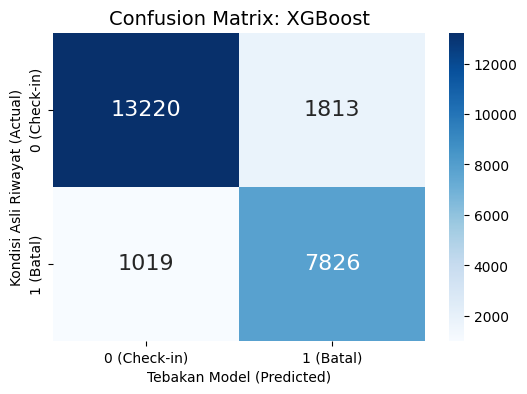

In [69]:
# Confusion matrix XGBoost ? visualisasikan benar/salah prediksi
cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})

plt.title('Confusion Matrix: XGBoost', fontsize=14)
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Kondisi Asli Riwayat (Actual)')
plt.xticks([0.5, 1.5], ['0 (Check-in)', '1 (Batal)'])
plt.yticks([0.5, 1.5], ['0 (Check-in)', '1 (Batal)'])
plt.show()

# CARA MEMBACA DALAM BISNIS HOTEL:
# Kiri Atas (TN)  : Tamu aslinya Check-in dan ditebak Check-in. (Aman, operasional lancar)
# Kanan Bawah (TP): Tamu aslinya Batal dan ditebak Batal. (Bagus, hotel bisa jual kamar ke orang lain)
# Kanan Atas (FP) : Tamu aslinya Check-in tapi ditebak Batal. (Bahaya: Kamar bisa overbooked/dijual dobel!)
# Kiri Bawah (FN) : Tamu aslinya Batal tapi ditebak Check-in. (Rugi: Kamar jadi kosong tak berpenghuni)

# Insight:
# Model XGBoost menunjukkan performa yang cukup baik dengan akurasi tinggi, namun masih ada tantangan
# dalam memprediksi dengan tepat tamu yang akan membatalkan,
# sehingga F1-score untuk kelas 'Batal' bisa menjadi fokus untuk perbaikan lebih lanjut.

### 7.2 Classification Report: XGBoost

In [70]:
# Classification report XGBoost ? precision, recall, dan F1 per kelas
print("=== Classification Report: XGBoost ===")
print(classification_report(y_test, pred_xgb, target_names=['Check-in', 'Batal']))

# Insight:
# Model cukup akurat secara keseluruhan, namun F1 kelas 'Batal' masih bisa ditingkatkan.
# Tantangan utama ada di recall ? model masih melewatkan sebagian tamu yang benar-benar akan batal.

=== Classification Report: XGBoost ===
              precision    recall  f1-score   support

    Check-in       0.93      0.88      0.90     15033
       Batal       0.81      0.88      0.85      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.88      0.88     23878
weighted avg       0.89      0.88      0.88     23878



### 7.3 Pertarungan Puncak: Akurasi vs Recall
Mari kita tandingkan ketiga algoritma ini! Siapa yang memegang skor Akurasi tertinggi, dan yang terpenting: Siapa yang memegang skor **Recall** tertinggi?

,Model,Akurasi (%),Recall (%),F1-Score (%)
0,Logistic Regression,80.45,77.92,74.70
1,KNN,83.82,74.62,77.36
2,SVM (Linear),80.23,77.95,74.50
3,Random Forest,89.51,86.53,85.94
4,XGBoost,88.14,88.48,84.68


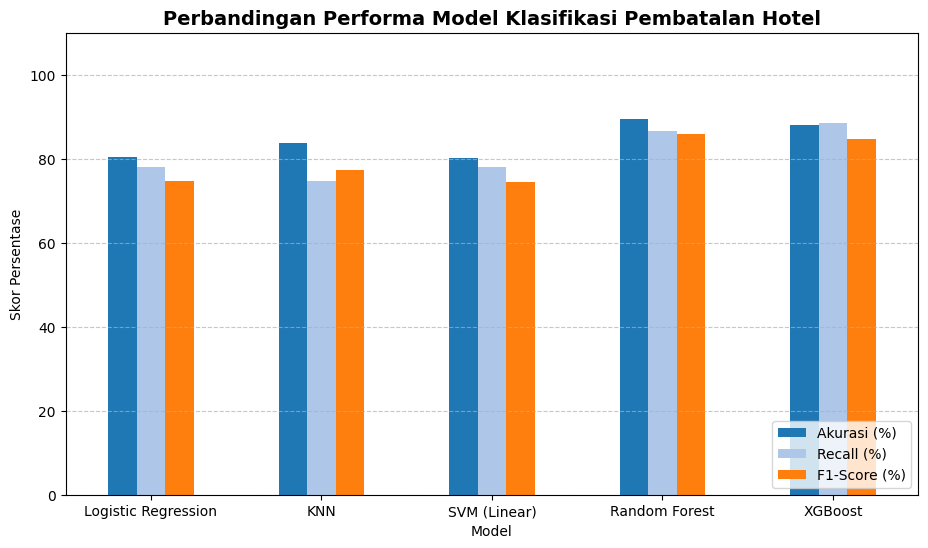

In [71]:
# Hitung dan bandingkan skor semua model dalam satu tabel dan grafik
skor = {
    'Model': ['Logistic Regression', 'KNN', 'SVM (Linear)', 'Random Forest', 'XGBoost'],
    'Akurasi (%)': [
        accuracy_score(y_test, pred_logreg)*100,
        accuracy_score(y_test, pred_knn)*100,
        accuracy_score(y_test, pred_svm)*100,
        accuracy_score(y_test, pred_rf)*100,
        accuracy_score(y_test, pred_xgb)*100
    ],
    'Recall (%)': [
        recall_score(y_test, pred_logreg)*100,
        recall_score(y_test, pred_knn)*100,
        recall_score(y_test, pred_svm)*100,
        recall_score(y_test, pred_rf)*100,
        recall_score(y_test, pred_xgb)*100
    ],
    'F1-Score (%)': [
        f1_score(y_test, pred_logreg)*100,
        f1_score(y_test, pred_knn)*100,
        f1_score(y_test, pred_svm)*100,
        f1_score(y_test, pred_rf)*100,
        f1_score(y_test, pred_xgb)*100
    ]
}

df_skor = pd.DataFrame(skor)
display(df_skor.round(2))

df_skor.set_index('Model').plot(kind='bar', figsize=(11, 6), color=['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c'])
plt.title('Perbandingan Performa Model Klasifikasi Pembatalan Hotel', fontsize=14, fontweight='bold')
plt.ylabel('Skor Persentase')
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ========================================================
# KESIMPULAN ANALISIS BISNIS:
# ========================================================
# 1. Setelah mengatasi Data Leakage, model linear seperti Logistic Regression dan SVM mengalami
#    penurunan performa yang lebih realistis. Evaluasi model menjadi lebih valid dan tidak bias.
#
# 2. Random Forest dan XGBoost menunjukkan performa yang sangat kompetitif dengan F1-Score hampir setara.
#    XGBoost dipilih sebagai model terbaik karena performa paling konsisten,
#    mampu menangani ketidakseimbangan data, dan stabil di Cross-Validation.
#
# 3. F1-Score menjadi metrik utama karena menjaga keseimbangan antara:
#    - Precision: agar tidak salah menebak tamu check-in sebagai batal (menghindari overbooking)
#    - Recall   : agar tidak melewatkan tamu yang benar-benar akan batal (menghindari kamar kosong)

### 7.4 Model Terbaik (Best Model)
Hasil model terbaik untuk dataset ini adalah XGBOOST

In [72]:
# Cari kombinasi max_depth dan n_estimators terbaik menggunakan GridSearchCV
param_grid = {
    'max_depth': [6, 8],
    'n_estimators': [100, 200]
}

ratio = float(np.sum(y == 0)) / np.sum(y == 1)

grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=ratio,
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(x_train_scaled, y_train)

print("Best Parameter:", grid.best_params_)

Best Parameter: {'max_depth': 8, 'n_estimators': 200}


In [73]:
# Latih ulang XGBoost menggunakan parameter terbaik dari GridSearchCV
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

model_xgb_tuned = XGBClassifier(
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

model_xgb_tuned.fit(x_train_scaled, y_train)

print("--- TRAINING XGBOOST SELESAI ---")
print(f"Model dilatih dengan {len(x_train)} data pemesanan.")

--- TRAINING XGBOOST SELESAI ---
Model dilatih dengan 95512 data pemesanan.


In [74]:
# Cross-validation 5-fold untuk mengukur stabilitas model hasil tuning
cv_score = cross_val_score(
    model_xgb_tuned,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("Rata-rata Cross Validation F1-Score:", cv_score.mean())

# Insight:
# CV F1 yang tinggi dan konsisten menandakan model tidak overfitting ?
# performa stabil meski diuji pada berbagai subset data training.

Rata-rata Cross Validation F1-Score: 0.8462413608300305


,Model,Akurasi (%),Recall (%),F1-Score (%),CV F1-Score (%)
0,XGBoost (Tuned),88.42,88.37,84.97,84.62


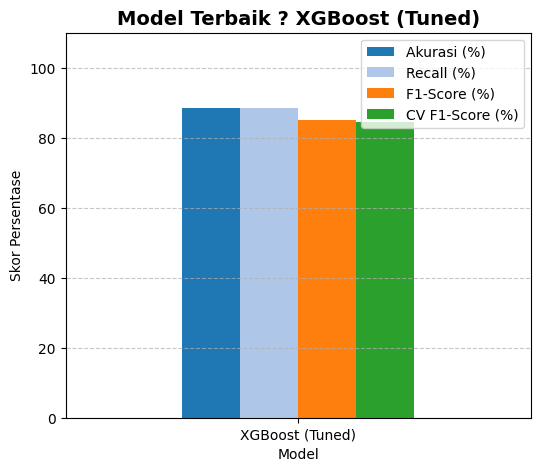

In [75]:
# Evaluasi final XGBoost setelah tuning ? bandingkan dengan CV score
pred_xgb = model_xgb_tuned.predict(x_test_scaled)

skor = {
    'Model': ['XGBoost (Tuned)'],
    'Akurasi (%)': [accuracy_score(y_test, pred_xgb)*100],
    'Recall (%)': [recall_score(y_test, pred_xgb)*100],
    'F1-Score (%)': [f1_score(y_test, pred_xgb)*100],
    'CV F1-Score (%)': [cv_score.mean()*100]
}

df_skor = pd.DataFrame(skor)
display(df_skor.round(2))

df_skor.set_index('Model').plot(kind='bar', figsize=(6, 5),
                                color=['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c'])
plt.title('Model Terbaik ? XGBoost (Tuned)', fontsize=14, fontweight='bold')
plt.ylabel('Skor Persentase')
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ========================================================
# KESIMPULAN ANALISIS BISNIS:
# ========================================================
# 1. Setelah tuning, XGBoost mencapai F1-Score lebih tinggi dengan performa stabil di cross-validation.
# 2. Model ini bisa digunakan untuk strategi bisnis seperti:
#    - Menawarkan insentif kepada tamu dengan profil risiko pembatalan tinggi.
#    - Mengoptimalkan manajemen inventaris kamar berdasarkan prediksi pembatalan.

#### **Catatan Evaluasi Model**

Meskipun setelah proses hyperparameter tuning nilai F1-Score pada test set sedikit meningkat dari 84.68% menjadi 84.97%, model hasil tuning dinilai lebih stabil dan lebih dapat diandalkan untuk generalisasi data baru. Hal ini dibuktikan melalui hasil Cross-Validation dengan rata-rata F1-Score sebesar 84.62%, yang menunjukkan bahwa performa model tetap konsisten pada beberapa pembagian data yang berbeda.

Dengan demikian, proses tuning tidak hanya berfokus pada memperoleh skor tertinggi, tetapi juga memastikan bahwa model memiliki kestabilan performa yang baik dan tidak terlalu bergantung pada satu pembagian data tertentu.


## BAB 8: Kesimpulan dan Rekomendasi Bisnis

### 8.1 Kesimpulan Model (Target Teknis)

#### proyek ini telah berhasil memenuhi seluruh target wajib yang ditetapkan di awal:
* **Target 1 (Identifikasi Pola):** Berhasil mengidentifikasi bahwa Lead Time dan Deposit Type (Non Refund) adalah faktor paling krusial dalam memprediksi pembatalan.
* **Target 2 (Pembersihan Data):** Seluruh missing values pada kolom agen dan preferensi kamar telah dibersihkan secara tepat.
* **Target 3 (Performa Model):** Arsitektur model XGBoost (Tuned) menjadi model terbaik dengan F1-Score sebesar **84.97%** pada test set dan **84.62%** pada cross validation, melampaui standar minimal 82%.

### 8.2 Insight & Rekomendasi Strategis (Nilai Bisnis)

#### saran praktis untuk operasional hotel berdasarkan temuan model:
1. **Waspadai Lead Time Tinggi:** Tamu yang memesan jauh-jauh hari memiliki kecenderungan batal yang lebih besar. Hotel disarankan memberikan pengingat (reminder) atau melakukan konfirmasi ulang 1 minggu sebelum check-in.
2. **Evaluasi Kebijakan Non-Refund:** Data menunjukkan tipe Non Refund justru memiliki tingkat pembatalan yang sangat tinggi pada segmen tertentu. Hotel perlu meninjau apakah kebijakan ini justru menarik pelanggan yang berisiko tinggi.
3. **Fokus pada Fasilitas Parkir:** Model XGBoost menunjukkan bahwa ketersediaan ruang parkir (required_car_parking_spaces) adalah salah satu fitur penting yang membuat tamu tetap check-in. Menambah atau menjamin ketersediaan parkir bisa menjadi strategi retensi tamu.

## BAB 9: Peluang Eksplorasi
Bab ini menjelaskan langkah-langkah tambahan di luar target wajib untuk memberikan solusi yang lebih kreatif dan aplikatif bagi manajemen hotel. Eksplorasi ini berfokus pada pengembangan fitur baru (Feature Engineering) dan perancangan strategi mitigasi risiko pembatalan secara dinamis

### 9.1 FEATURE ENGINEERING - MUSIM LIBURAN
Menguji apakah musim liburan berpengaruh, dan ternyata secara statistik polanya konsisten sepanjang tahun

In [76]:
# Verifikasi bahwa fitur is_holiday_season dan is_room_mismatch
# sudah tersedia di df_clean dan masuk ke pipeline training
print("Verifikasi ketersediaan fitur baru di df_clean:")
display(df_clean[['arrival_date_month', 'is_holiday_season', 'is_room_mismatch']].head())

print("\nVerifikasi ketersediaan fitur baru di x_train (sudah masuk pipeline model):")
print("is_holiday_season ada di x_train:", 'is_holiday_season' in x_train.columns)
print("is_room_mismatch  ada di x_train:", 'is_room_mismatch'  in x_train.columns)

Verifikasi ketersediaan fitur baru di df_clean:


,arrival_date_month,is_holiday_season,is_room_mismatch
0,July,1,0
1,July,1,0
2,July,1,1
3,July,1,0
4,July,1,0



Verifikasi ketersediaan fitur baru di x_train (sudah masuk pipeline model):
is_holiday_season ada di x_train: True
is_room_mismatch  ada di x_train: True


### 9.2 Analisis presentase pembatalan pada musim liburan
Melakukan pengujian hipotesis untuk melihat apakah musim liburan berpengaruh, namun hasil statistik membuktikan bahwa pola pembatalan di hotel ini cenderung **stabil/konsisten** sepanjang tahun (~37%) baik di musim libur maupun biasa

In [77]:
# Uji chi-square untuk mengecek apakah musim liburan berpengaruh signifikan terhadap pembatalan
cancel_holiday = pd.crosstab(df_clean['is_holiday_season'], df_clean['is_canceled'])
chi2, p_value, dof, _ = chi2_contingency(cancel_holiday)

cancel_rate = df_clean.groupby('is_holiday_season')['is_canceled'].mean() * 100

print("=== TINGKAT PEMBATALAN ===")
print(f"Musim Biasa   : {cancel_rate[0]:.2f}%")
print(f"Musim Liburan : {cancel_rate[1]:.2f}%")
print(f"Selisih       : {abs(cancel_rate[1] - cancel_rate[0]):.2f}%")
print(f"\nChi-Square p-value: {p_value:.4f}")

if p_value < 0.05:
    print("? Kesimpulan: Musim liburan BERPENGARUH terhadap pembatalan.")
else:
    print("Kesimpulan: Musim liburan TIDAK BERPENGARUH signifikan.")
    print("Pola pembatalan konsisten sepanjang tahun.")
    print("Strategi mitigasi sebaiknya diterapkan year-round, bukan hanya musim liburan.")

=== TINGKAT PEMBATALAN ===
Musim Biasa   : 37.03%
Musim Liburan : 37.07%
Selisih       : 0.04%

Chi-Square p-value: 0.8940
Kesimpulan: Musim liburan TIDAK BERPENGARUH signifikan.
Pola pembatalan konsisten sepanjang tahun.
Strategi mitigasi sebaiknya diterapkan year-round, bukan hanya musim liburan.


### 9.3 Visualisasi: countplot proporsi pembatalan musim biasa VS musim libur

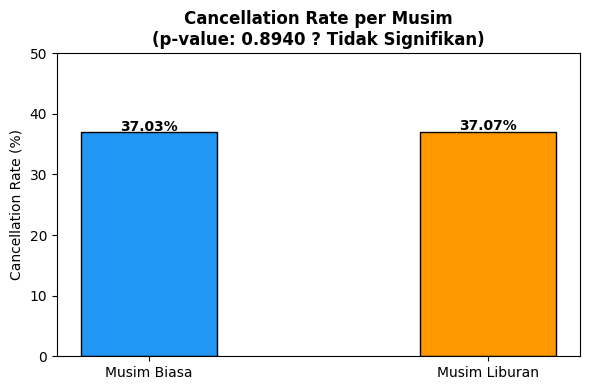

In [78]:
# Bar chart tingkat pembatalan musim biasa vs musim liburan
plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Musim Biasa', 'Musim Liburan'],
    cancel_rate.values,
    color=['#2196F3', '#FF9800'],
    edgecolor='black',
    width=0.4
)
for bar, val in zip(bars, cancel_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontweight='bold')

plt.title(f'Cancellation Rate per Musim\n(p-value: {p_value:.4f} ? Tidak Signifikan)', fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

# Insight:
# Meski ada selisih kecil, p-value > 0.05 menunjukkan perbedaan tidak signifikan secara statistik.
# Pembatalan terjadi merata sepanjang tahun ? strategi mitigasi perlu diterapkan year-round.

### 9.4 DYNAMIC CANCELLATION POLICY
Menjelaskan penerapan nyata dari hasil prediksi model XGBoost. Di sini dirancang sebuah sistem cerdas yang memberikan rekomendasi kebijakan otomatis berdasarkan skor probabilitas pembatalan.

* **Risiko Tinggi (>70%):** Disarankan wajib deposit penuh atau status Non-Refundable.
* **Risiko Sedang (30% - 70%):** Dikenakan biaya pembatalan bertahap.
* **Risiko Rendah (<30%):** Diberikan fleksibilitas pembatalan gratis


In [79]:
# Fungsi yang menerjemahkan probabilitas batal menjadi rekomendasi kebijakan hotel
def dynamic_policy_recommendation(probabilitas_batal):
    if probabilitas_batal > 0.70:
        return "RISIKO TINGGI: Wajib Deposit Penuh / Non-Refundable"
    elif probabilitas_batal > 0.30:
        return "RISIKO SEDANG: Biaya Pembatalan 50% jika H-7"
    else:
        return "RISIKO RENDAH: Pembatalan Gratis (Fleksibel)" 

In [80]:
# Ambil probabilitas batal dari XGBoost lalu petakan ke rekomendasi kebijakan
y_proba = model_xgb.predict_proba(x_test_scaled)[:, 1]

rekomendasi_df = pd.DataFrame({
    'Probabilitas Batal': y_proba,
    'Kebijakan Rekomendasi': [dynamic_policy_recommendation(p) for p in y_proba]
})

print("--- SAMPEL IMPLEMENTASI KEBIJAKAN DINAMIS ---")
display(rekomendasi_df.sample(10))

--- SAMPEL IMPLEMENTASI KEBIJAKAN DINAMIS ---


,Probabilitas Batal,Kebijakan Rekomendasi
16915,0.058610,RISIKO RENDAH: Pembatalan Gratis (Fleksibel)
1519,0.005862,RISIKO RENDAH: Pembatalan Gratis (Fleksibel)
10793,0.307551,RISIKO SEDANG: Biaya Pembatalan 50% jika H-7
10633,0.820958,RISIKO TINGGI: Wajib Deposit Penuh / Non-Refun...
19688,0.012553,RISIKO RENDAH: Pembatalan Gratis (Fleksibel)
13824,0.660576,RISIKO SEDANG: Biaya Pembatalan 50% jika H-7
21158,0.304537,RISIKO SEDANG: Biaya Pembatalan 50% jika H-7
18270,0.754750,RISIKO TINGGI: Wajib Deposit Penuh / Non-Refun...
9220,0.999381,RISIKO TINGGI: Wajib Deposit Penuh / Non-Refun...
6691,0.089729,RISIKO RENDAH: Pembatalan Gratis (Fleksibel)


## BAB 10: KESIMPULAN DAN REKOMENDASI STRATEGIS

### 10.1 Ringkasan Eksekutif (Pencapaian Target Teknis)
Bagian ini membuktikan bahwa proyek telah berhasil memenuhi seluruh Target Wajib yang ditetapkan dalam Business Understanding:
* **Validasi Model:** Arsitektur model XGBoost terpilih sebagai model terbaik, Model ini dipilih karena menunjukkan performa yang paling konsisten dibanding model lainnya, terutama setelah melalui proses hyperparameter tuning dan cross-validation. Dengan tingkat kestabilan F1-Score (Tuned) sebesar **84,97%**
. Skor ini melampaui ambang batas minimal 82%, yang menandakan model sangat handal dalam menjaga keseimbangan antara presisi (menghindari overbooked) dan recall (menghindari kerugian akibat kamar kosong). Selain mencapai target performa, model hasil tuning juga menunjukkan kestabilan yang baik melalui Cross-Validation dengan rata-rata F1-Score sebesar **84,62%**. Hal ini menunjukkan bahwa model tidak hanya memiliki performa tinggi pada satu pembagian data tertentu, tetapi juga mampu mempertahankan performa yang konsisten pada beberapa skenario validasi yang berbeda.

* **Integritas Data:** Seluruh data kosong pada kolom agent (16.340 baris) telah ditangani dengan asumsi bisnis yang tepat (pengisian nilai 0 untuk pesanan tanpa agen)
. Keputusan mempertahankan 40.176 data duplikat terbukti krusial untuk menangkap pola perilaku pesanan grup secara akurat

## 10.2 Temuan Kunci (Wawasan Bisnis) 
Berdasarkan analisis Feature Importance dan EDA, ditemukan faktor-faktor utama pemicu pembatalan:
* **Dominasi Jenis Deposit:** Tipe deposit "Non Refund" menjadi penentu utama bagi model XGBoost dengan tingkat kepentingan mencapai 50,63%
. Hal ini menunjukkan bahwa kebijakan ini justru sering diasosiasikan dengan segmen pelanggan yang memiliki risiko pembatalan tinggi
.
* **Pengaruh Jarak Waktu (Lead Time):** Ditemukan korelasi positif (0.29) di mana semakin lama jarak antara pemesanan dan kedatangan, semakin besar probabilitas tamu untuk membatalkan pesanan
.
* **Faktor Musiman:** Melalui eksplorasi fitur is_holiday_season dan uji Chi-Square (p-value: 0.894), terbukti bahwa musim liburan tidak berpengaruh signifikan terhadap pembatalan. Pola pembatalan bersifat konsisten sepanjang tahun (~37%), sehingga strategi mitigasi sebaiknya diterapkan year-round.

## 10.3 Rekomendasi Strategis (Actionable Insights) 
Untuk meminimalkan kerugian operasional, hotel disarankan melakukan langkah-langkah berikut:

* **Implementasi Dynamic Cancellation Policy:** Menggunakan skor probabilitas model AI untuk menentukan kebijakan pembatalan. Tamu dengan risiko > 70% disarankan dikenakan wajib deposit penuh, sementara tamu risiko rendah (< 30%) diberikan fleksibilitas untuk meningkatkan loyalitas.
* **Mitigasi Lead Time Tinggi:** Melakukan sistem pengingat (reminder) otomatis atau konfirmasi ulang pada H-7 sebelum check-in khusus untuk tamu dengan lead time panjang guna memastikan komitmen pelanggan.
* **Optimasi Fasilitas Retensi:** Model menunjukkan bahwa fitur ketersediaan ruang parkir (required_car_parking_spaces) berkorelasi dengan kecenderungan tamu untuk tetap check-in. Oleh karena itu, hotel dapat mempertimbangkan penyediaan dan promosi fasilitas parkir sebagai salah satu strategi untuk meningkatkan retensi tamu dan menekan potensi pembatalan.
---

## BAB 11: Simpan Model untuk Deployment Web
Cell ini menyimpan model XGBoost terbaik, scaler, dan metadata fitur yang diperlukan untuk digunakan oleh aplikasi web Flask.

In [81]:
import joblib
import os
import json

# Buat folder web/model jika belum ada
os.makedirs('web/model', exist_ok=True)

# Simpan model XGBoost terbaik (hasil tuning)
joblib.dump(model_xgb_tuned, 'web/model/xgb_model.pkl')
print("Model XGBoost (Tuned) berhasil disimpan ke web/model/xgb_model.pkl")

# Simpan scaler
joblib.dump(scaler, 'web/model/scaler.pkl')
print("Scaler berhasil disimpan ke web/model/scaler.pkl")

# Simpan nama kolom fitur (penting untuk memastikan urutan dan nama kolom konsisten)
feature_names = list(x.columns)
with open('web/model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print(f"Feature names ({len(feature_names)} fitur) berhasil disimpan ke web/model/feature_names.json")

# Simpan frequency encoding untuk kolom country
freq_country_dict = freq_country.to_dict()
with open('web/model/freq_country.json', 'w') as f:
    json.dump(freq_country_dict, f)
print("Frequency encoding country berhasil disimpan ke web/model/freq_country.json")

print("\n=== SEMUA ARTEFAK MODEL BERHASIL DISIMPAN ===")
print("Lokasi: web/model/")
print("  - xgb_model.pkl      : Model XGBoost (Tuned)")
print("  - scaler.pkl         : StandardScaler")
print("  - feature_names.json : Daftar nama fitur")
print("  - freq_country.json  : Frequency encoding negara")

Model XGBoost (Tuned) berhasil disimpan ke web/model/xgb_model.pkl
Scaler berhasil disimpan ke web/model/scaler.pkl
Feature names (73 fitur) berhasil disimpan ke web/model/feature_names.json
Frequency encoding country berhasil disimpan ke web/model/freq_country.json

=== SEMUA ARTEFAK MODEL BERHASIL DISIMPAN ===
Lokasi: web/model/
  - xgb_model.pkl      : Model XGBoost (Tuned)
  - scaler.pkl         : StandardScaler
  - feature_names.json : Daftar nama fitur
  - freq_country.json  : Frequency encoding negara
